# Assignment 2-2: Kentucky County Lung Cancer Mortality (Python Replication)

**Author:** Tolulope  Oladeji
**Context:** Python replication of an ArcGIS Pro exercise from *GIS Tutorial for Health* (Kurland & Gorr).
**Original curriculum:** Designed by Dr. Diego Cuadros (UC Digital Epidemiology Laboratory).
**Builds on:** Assignment 2-1, which identified Kentucky as a high-burden state for both Black and White male lung cancer mortality.

---

## Objective

Produce a detailed county-level analysis of lung cancer mortality in Kentucky (2000–2004), targeted at a state health official. Specifically:

1. Load county-level mortality data and major U.S. cities, filtered to Kentucky.
2. Identify counties with **Black male mortality rate > 150** per 100,000 (Map A).
3. Identify counties with **White male mortality rate > 150** per 100,000 (Map B).
4. Identify the **top five counties** by total count of male lung cancer deaths (Map C).
5. Produce an integrated overview map of all layers (Map D).
6. Identify counties meeting **both** thresholds — the cross-population priority targets.

## Data Dictionary

| Attribute     | Definition                                                                  |
|---------------|-----------------------------------------------------------------------------|
| `RWM00_04`    | Mortality rate per 100,000 — White males, 2000–2004                         |
| `RBM00_04`    | Mortality rate per 100,000 — Black males, 2000–2004                         |
| `CWMBM00_04`  | Count of White and Black male lung cancer deaths, 2000–2004                 |

## Deliverables

- Four individual JPEGs (Maps A through D) matching the ArcGIS Pro assignment specification.
- One 2×2 summary figure compositing all four perspectives for at-a-glance comparison.
- Identification of overlap counties for the PowerPoint summary slide.


In [11]:
# 1. Imports
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
from matplotlib.patches import Patch
import pandas as pd
import pyogrio

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

print(f"geopandas: {gpd.__version__}")
print(f"pyogrio:   {pyogrio.__version__}")

geopandas: 1.0.1
pyogrio:   0.9.0


In [13]:
# 2. Configuration
# Relative paths — to run this notebook, place the textbook geodatabases inside:
#     <project_root>/data/NCI.gdb
#     <project_root>/data/UnitedStates.gdb

HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == "notebooks" else HERE

DATA_DIR   = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MAPS_DIR   = OUTPUT_DIR / "maps"
TABLES_DIR = OUTPUT_DIR / "tables"

# Geodatabases for this assignment
NCI_GDB = DATA_DIR / "NCI.gdb"
US_GDB  = DATA_DIR / "UnitedStates.gdb"

# Layers
COUNTY_LAYER = "LungCounty"
STATE_LAYER  = "LungState"
CITY_LAYER   = "USMajorCities"

# Standard CONUS projection
CONUS_CRS = "EPSG:5070"

MAPS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# --- Diagnostics ---
print(f"Project root : {PROJECT_ROOT}")
print()
print(f"NCI.gdb path        : {NCI_GDB}")
print(f"   exists?          : {NCI_GDB.exists()}")
print(f"UnitedStates.gdb    : {US_GDB}")
print(f"   exists?          : {US_GDB.exists()}")

missing = []
if not NCI_GDB.exists():
    missing.append("NCI.gdb")
if not US_GDB.exists():
    missing.append("UnitedStates.gdb")

if missing:
    print(f"\n Missing geodatabases: {', '.join(missing)}")
    print(f"    Copy them from your textbook data folder into: {DATA_DIR}")
    print(f"    Note: if UnitedStates.gdb shows the OneDrive 'syncing' icon (blue arrows),")
    print(f"    right-click and choose 'Always keep on this device' before copying.")
else:
    print(f"\n Both geodatabases located. Ready to load layers.")

Project root : C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)

NCI.gdb path        : C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\data\NCI.gdb
   exists?          : True
UnitedStates.gdb    : C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\data\UnitedStates.gdb
   exists?          : True

 Both geodatabases located. Ready to load layers.


## Step 1: Inspect available layers

Before loading, list what is in each geodatabase. This confirms layer names and surfaces any other useful datasets.

In [16]:
# 3. List available layers in each geodatabase
print("NCI.gdb layers:")
for name, geom in pyogrio.list_layers(NCI_GDB):
    print(f"   - {name:30s} ({geom})")

print("\nUnitedStates.gdb layers:")
for name, geom in pyogrio.list_layers(US_GDB):
    print(f"   - {name:30s} ({geom})")

NCI.gdb layers:
   - BreCounty                      (MultiPolygon)
   - LungState                      (MultiPolygon)
   - LungCounty                     (MultiPolygon)
   - BreState                       (MultiPolygon)

UnitedStates.gdb layers:
   - NEBlocks                       (MultiPolygon)
   - NEHRR                          (MultiPolygon)
   - NEHSA                          (MultiPolygon)
   - USZipCodes                     (MultiPolygon)
   - USCities_dtl                   (Point)
   - USCities                       (Point)
   - USCounties                     (MultiPolygon)
   - PACounties                     (MultiPolygon)
   - USMajorCities                  (Point)
   - HarrisCountyCities             (Point)
   - NECities                       (Point)
   - USStates                       (MultiPolygon)
   - USInterstates                  (MultiLineString)
   - USLakes                        (MultiPolygon)
   - USRivers                       (MultiLineString)
   - CATracts     

## Step 2: Load the three input layers

We load `LungState`, `LungCounty`, and `USMajorCities`, then inspect each for the column conventions used in the textbook dataset.

In [19]:
# 4. Load LungCounty
counties_all = gpd.read_file(NCI_GDB, layer=COUNTY_LAYER)
print(f"LungCounty: {len(counties_all)} records, CRS: {counties_all.crs}")
print(f"Columns: {list(counties_all.columns)}")
counties_all.head(2)

LungCounty: 3055 records, CRS: EPSG:4269
Columns: ['ID_', 'OBJECTID', 'NAME2_', 'LENGTH_', 'AREA_', 'STATE_NAME', 'STATE_ABBR', 'RWM90_94', 'CWM90_94', 'RWF90_94', 'CWF90_94', 'RBM90_94', 'CBM90_94', 'RBF90_94', 'CBF90_94', 'RWM95_99', 'CWM95_99', 'RWF95_99', 'CWF95_99', 'RBM95_99', 'CBM95_99', 'RBF95_99', 'CBF95_99', 'RWM00_04', 'CWM00_04', 'RWF00_04', 'CWF00_04', 'RBM00_04', 'CBM00_04', 'RBF00_04', 'CBF00_04', 'CWMBM90_94', 'CWFBF90_94', 'CWMBM95_99', 'CWFBF95_99', 'CWMBM00_04', 'CWFBF00_04', 'C_ALL_90_94', 'C_ALL_95_99', 'C_ALL_00_04', 'CHANGE_ALL_95_04', 'Shape_Length', 'Shape_Area', 'geometry']


,ID_,OBJECTID,NAME2_,LENGTH_,AREA_,STATE_NAME,STATE_ABBR,RWM90_94,CWM90_94,RWF90_94,CWF90_94,RBM90_94,CBM90_94,RBF90_94,CBF90_94,...,RBF00_04,CBF00_04,CWMBM90_94,CWFBF90_94,CWMBM95_99,CWFBF95_99,CWMBM00_04,CWFBF00_04,C_ALL_90_94,C_ALL_95_99,C_ALL_00_04,CHANGE_ALL_95_04,Shape_Length,Shape_Area,geometry
0,01001,1.0,AUTAUGA,119.1182,608.4207,Alabama,AL,127.4209,65.0,38.7200,28.0,176.2422,21.0,22.3676,4.0,...,51.9053,10.0,86.0,32.0,97.0,51.0,81.0,49.0,118,148,130,-18.0,1.866906,0.151003,"MULTIPOLYGON (((-86.4972 32.34429, -86.53161 3..."
1,01003,2.0,BALDWIN,248.7494,1682.9250,Alabama,AL,95.0521,250.0,46.2199,151.0,85.7899,19.0,32.6565,10.0,...,38.4796,13.0,269.0,161.0,300.0,170.0,341.0,222.0,430,470,563,93.0,3.894317,0.408436,"MULTIPOLYGON (((-87.5484 30.27628, -87.8204 30..."


In [21]:
# 5. Load LungState
states_all = gpd.read_file(NCI_GDB, layer=STATE_LAYER)
print(f"LungState: {len(states_all)} records, CRS: {states_all.crs}")
print(f"Columns: {list(states_all.columns)}")

LungState: 51 records, CRS: EPSG:4269
Columns: ['ID_', 'NAME1_', 'NAME2_', 'POINTS_', 'LENGTH_', 'AREA_', 'RWM95_99', 'CWM95_99', 'RWF95_99', 'CWF95_99', 'RBM95_99', 'CBM95_99', 'RBF95_99', 'CBF95_99', 'RWM00_04', 'CWM00_04', 'RWF00_04', 'CWF00_04', 'RBM00_04', 'CBM_00_04', 'RBF00_04', 'CBF00_04', 'CWMBM95_99', 'CWFBF95_99', 'CWMBM00_04', 'CWFBF00_04', 'C_ALL_95_99', 'C_ALL_00_04', 'CHANGE_ALL_95_04', 'Shape_Length', 'Shape_Area', 'geometry']


In [23]:
# 6. Load USMajorCities
cities_all = gpd.read_file(US_GDB, layer=CITY_LAYER)
print(f"USMajorCities: {len(cities_all)} records, CRS: {cities_all.crs}")
print(f"Columns: {list(cities_all.columns)}")
cities_all.head(2)

USMajorCities: 137 records, CRS: EPSG:4326
Columns: ['NAME', 'CLASS', 'ST', 'STFIPS', 'PLACEFIP', 'CAPITAL', 'AREALAND', 'AREAWATER', 'POP_CLASS', 'POP2000', 'POP2007', 'WHITE', 'BLACK', 'AMERI_ES', 'ASIAN', 'HAWN_PI', 'OTHER', 'MULT_RACE', 'HISPANIC', 'MALES', 'FEMALES', 'AGE_UNDER5', 'AGE_5_17', 'AGE_18_21', 'AGE_22_29', 'AGE_30_39', 'AGE_40_49', 'AGE_50_64', 'AGE_65_UP', 'MED_AGE', 'MED_AGE_M', 'MED_AGE_F', 'HOUSEHOLDS', 'AVE_HH_SZ', 'HSEHLD_1_M', 'HSEHLD_1_F', 'MARHH_CHD', 'MARHH_NO_C', 'MHH_CHILD', 'FHH_CHILD', 'FAMILIES', 'AVE_FAM_SZ', 'HSE_UNITS', 'VACANT', 'OWNER_OCC', 'RENTER_OCC', 'geometry']


,NAME,CLASS,ST,STFIPS,PLACEFIP,CAPITAL,AREALAND,AREAWATER,POP_CLASS,POP2000,POP2007,WHITE,BLACK,AMERI_ES,ASIAN,...,HOUSEHOLDS,AVE_HH_SZ,HSEHLD_1_M,HSEHLD_1_F,MARHH_CHD,MARHH_NO_C,MHH_CHILD,FHH_CHILD,FAMILIES,AVE_FAM_SZ,HSE_UNITS,VACANT,OWNER_OCC,RENTER_OCC,geometry
0,Spokane,City,WA,53,67000,,57.758,0.764,8,195629,204529,175018,4052,3444,4399,...,81512,2.32,11834,15801,14987,18717,2144,6806,47256,2.98,87941,6429,47915,33597,POINT (-117.41027 47.67335)
1,Boise City,City,ID,16,08830,State,63.776,0.206,8,185787,203529,171204,1437,1300,3870,...,74438,2.44,9176,11653,17536,18735,1695,4934,46493,3.03,77850,3412,47638,26800,POINT (-116.23765 43.61374)


## Step 3: Define column mappings

Confirm or adjust the column names below to match what was printed above. The textbook's `LungState` and `LungCounty` use the ArcInfo coverage convention (`NAME1_` for abbreviation, `NAME2_` for full name). `USMajorCities` uses standard ESRI conventions.

In [33]:
# 7. Column mappings — adjusted to handle the textbook's inconsistent conventions

# LungState (uses ArcInfo coverage convention only)
STATE_LAYER_NAME_COL = "NAME2_"        # full state name in LungState
STATE_LAYER_ABBR_COL = "NAME1_"        # state abbr in LungState

# LungCounty (uses BOTH conventions — has STATE_NAME for state AND NAME2_ for county)
COUNTY_LAYER_STATE_COL = "STATE_NAME"  # state name column IN LungCounty (used for filtering)
COUNTY_NAME_COL        = "NAME2_"      # county name in LungCounty

# USMajorCities — standard ESRI conventions
CITY_NAME_COL  = "NAME"
CITY_STATE_COL = "ST"

# Verify the city columns exist
if CITY_NAME_COL not in cities_all.columns:
    print(f" '{CITY_NAME_COL}' not found in USMajorCities. Candidates:")
    print([c for c in cities_all.columns if 'NAME' in c.upper() or 'CITY' in c.upper()])
if CITY_STATE_COL not in cities_all.columns:
    print(f" '{CITY_STATE_COL}' not found in USMajorCities. Candidates:")
    print([c for c in cities_all.columns if 'ST' in c.upper() or 'STATE' in c.upper()])

print(f"LungState  filter column : {STATE_LAYER_NAME_COL}")
print(f"LungCounty filter column : {COUNTY_LAYER_STATE_COL}")
print(f"County name column       : {COUNTY_NAME_COL}")
print(f"City name / state cols   : {CITY_NAME_COL} / {CITY_STATE_COL}")

LungState  filter column : NAME2_
LungCounty filter column : STATE_NAME
County name column       : NAME2_
City name / state cols   : NAME / ST


## Step 4: Filter to Kentucky

The ArcGIS Pro equivalent of this step is *Zoom to Kentucky* plus saving a spatial bookmark. In Python, we explicitly subset each layer.

In [35]:
# 8. Filter each layer to Kentucky and reproject to a common CRS

ky_state    = states_all[states_all[STATE_LAYER_NAME_COL] == "Kentucky"].to_crs(CONUS_CRS)
ky_counties = counties_all[counties_all[COUNTY_LAYER_STATE_COL] == "Kentucky"].to_crs(CONUS_CRS)

# Cities — try state abbreviation first, fall back to spatial filter
if CITY_STATE_COL in cities_all.columns:
    ky_cities = cities_all[cities_all[CITY_STATE_COL].isin(["KY", "Kentucky"])].to_crs(CONUS_CRS)
else:
    ky_cities = cities_all[cities_all.geometry.within(ky_state.geometry.union_all())].to_crs(CONUS_CRS)

print(f"Kentucky state outline   : {len(ky_state)} record")
print(f"Kentucky counties        : {len(ky_counties)} records")
print(f"Kentucky major cities    : {len(ky_cities)} records")

if len(ky_cities) > 0:
    print(f"\nCity names: {sorted(ky_cities[CITY_NAME_COL].tolist())}")

Kentucky state outline   : 1 record
Kentucky counties        : 120 records
Kentucky major cities    : 2 records

City names: ['Lexington', 'Louisville']


In [37]:
# 9. Descriptive statistics for Kentucky counties
ky_counties[["RWM00_04", "RBM00_04", "CWMBM00_04"]].describe().round(2)

,RWM00_04,RBM00_04,CWMBM00_04
count,120.00,120.00,120.00
mean,117.34,116.97,83.58
std,27.21,184.99,151.37
min,57.43,0.00,6.00
25%,100.88,0.00,32.00
50%,113.14,74.34,49.00
75%,131.80,151.01,90.50
max,214.82,1079.43,1582.00


## Step 5: Define the four county selections

| Map | Selection criterion                                                              |
|-----|----------------------------------------------------------------------------------|
| A   | Counties where Black male mortality rate (`RBM00_04`) > 150                      |
| B   | Counties where White male mortality rate (`RWM00_04`) > 150                      |
| C   | Top five counties by combined male death count (`CWMBM00_04`)                    |
| D   | All layers — counties, state outline, cities (overview)                          |

We also identify **overlap counties** that meet both Map A and Map B criteria simultaneously.

In [39]:
# 10. Define the four selections
#
# IMPORTANT methodological note: RBM00_04 contains placeholder zeros for counties
# with no/very small Black populations. We treat these as missing before applying
# the threshold, since a literal zero rate is not epidemiologically meaningful here.
# RWM00_04 does not have this issue (every KY county has a substantial White population).

# Mark placeholder zeros in RBM00_04 as missing for selection purposes
rbm_valid = ky_counties["RBM00_04"].replace(0, pd.NA)

sel_black = ky_counties[(rbm_valid.notna()) & (rbm_valid > 150)].copy()
sel_white = ky_counties[ky_counties["RWM00_04"] > 150].copy()
sel_top5_count = ky_counties.nlargest(5, "CWMBM00_04").copy()

# Overlap: counties in BOTH sel_black AND sel_white
overlap_names = set(sel_black[COUNTY_NAME_COL]) & set(sel_white[COUNTY_NAME_COL])
overlap_counties = ky_counties[ky_counties[COUNTY_NAME_COL].isin(overlap_names)].copy()

print(f"Map A — Black male mortality > 150 : {len(sel_black)} counties")
print(f"Map B — White male mortality > 150 : {len(sel_white)} counties")
print(f"Map C — Top 5 by death count       : {len(sel_top5_count)} counties")
print(f"\nOverlap (both A AND B)            : {len(overlap_counties)} counties")
print(f"   {sorted(overlap_names)}")

# Also report how many counties were excluded due to the zero-placeholder
n_zero_rbm = (ky_counties["RBM00_04"] == 0).sum()
print(f"\n[Note] {n_zero_rbm} counties had RBM00_04 = 0 (treated as missing/no Black population).")

Map A — Black male mortality > 150 : 31 counties
Map B — White male mortality > 150 : 14 counties
Map C — Top 5 by death count       : 5 counties

Overlap (both A AND B)            : 2 counties
   ['GALLATIN', 'KNOX']

[Note] 55 counties had RBM00_04 = 0 (treated as missing/no Black population).


In [41]:
# 11. Display the selected counties as ranked tables

print("Map A — Counties with Black male mortality > 150 (sorted highest to lowest):\n")
print(sel_black[[COUNTY_NAME_COL, "RBM00_04", "RWM00_04", "CWMBM00_04"]]
      .sort_values("RBM00_04", ascending=False)
      .to_string(index=False))

print("\n\nMap B — Counties with White male mortality > 150 (sorted highest to lowest):\n")
print(sel_white[[COUNTY_NAME_COL, "RWM00_04", "RBM00_04", "CWMBM00_04"]]
      .sort_values("RWM00_04", ascending=False)
      .to_string(index=False))

print("\n\nMap C — Top 5 counties by total male lung cancer death count:\n")
print(sel_top5_count[[COUNTY_NAME_COL, "CWMBM00_04", "RBM00_04", "RWM00_04"]]
      .sort_values("CWMBM00_04", ascending=False)
      .to_string(index=False))

Map A — Counties with Black male mortality > 150 (sorted highest to lowest):

    NAME2_  RBM00_04  RWM00_04  CWMBM00_04
   BULLITT 1079.4259  109.7410       122.0
   SPENCER  930.4744   57.4326        17.0
     ROWAN  794.3250   99.2066        44.0
     FLOYD  610.6900  142.7695       137.0
   GARRARD  585.6784   82.8493        30.0
      OHIO  537.7619  122.8720        74.0
   BALLARD  474.7337  139.0740        30.0
  GALLATIN  449.9833  181.0395        29.0
      LYON  393.4321   87.1530        25.0
     BOONE  387.7000  109.4538       140.0
CUMBERLAND  342.6400   78.6093        18.0
  WOODFORD  290.0513   86.4155        42.0
     LOGAN  250.0982  107.3782        74.0
    NELSON  239.5064   90.2393        72.0
MUHLENBERG  234.3856  129.9643       107.0
  CALDWELL  231.7982  107.7485        42.0
   PULASKI  217.3816  117.6005       182.0
     GREEN  212.4672  113.9393        38.0
     HENRY  203.5176  143.0559        49.0
  FRANKLIN  203.4753  126.3831       132.0
      CLAY  195.387

## Step 6: Cartographic helper function

A single function handles all four maps. Each map is produced by passing a different `highlight` GeoDataFrame and color scheme into this helper, ensuring consistent styling across deliverables and the summary figure.

In [44]:
# 12. Reusable Kentucky map plotting function

def plot_kentucky_lung_cancer_map(
    ax,
    highlight=None,
    highlight_color="darkred",
    highlight_alpha=0.65,
    highlight_label="Selected counties",
    title=None,
    label_highlighted=True,
    label_cities=True,
    show_legend=True,
):
    """Plot a single Kentucky lung cancer map onto a matplotlib axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    highlight : GeoDataFrame or None
        Counties to highlight (e.g., above-threshold or top-N selections).
    highlight_color : str
        Fill color for highlighted counties.
    highlight_alpha : float
        Transparency for highlighted counties (0–1).
    highlight_label : str
        Legend entry for the highlighted set.
    title : str
        Map title.
    label_highlighted : bool
        Whether to label each highlighted county.
    label_cities : bool
        Whether to label major cities.
    show_legend : bool
        Whether to render the legend.
    """
    # Kentucky state outline — hollow fill, black outline (per ArcGIS spec)
    ky_state.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2.0)

    # All Kentucky counties — hollow fill, gray outline
    ky_counties.plot(ax=ax, facecolor="none", edgecolor="dimgray", linewidth=0.5)

    # Highlighted counties (if any)
    if highlight is not None and len(highlight) > 0:
        highlight.plot(
            ax=ax,
            facecolor=highlight_color,
            edgecolor="black",
            linewidth=1.0,
            alpha=highlight_alpha,
        )
        if label_highlighted:
            for _, row in highlight.iterrows():
                c = row.geometry.representative_point()
                txt = ax.annotate(
                    text=str(row[COUNTY_NAME_COL])[:14],
                    xy=(c.x, c.y),
                    ha="center", va="center",
                    fontsize=6, fontweight="bold", color="black",
                )
                txt.set_path_effects([
                    PathEffects.withStroke(linewidth=1.5, foreground="yellow")
                ])

    # Major cities — black circles
    if len(ky_cities) > 0:
        ky_cities.plot(ax=ax, color="black", markersize=40, marker="o", zorder=5)
        if label_cities:
            for _, row in ky_cities.iterrows():
                txt = ax.annotate(
                    text=row[CITY_NAME_COL],
                    xy=(row.geometry.x, row.geometry.y),
                    xytext=(6, 6), textcoords="offset points",
                    fontsize=8, fontweight="bold", color="black",
                )
                txt.set_path_effects([
                    PathEffects.withStroke(linewidth=2, foreground="yellow")
                ])

    # Legend
    if show_legend and highlight is not None and len(highlight) > 0:
        legend_elements = [
            Patch(facecolor=highlight_color, alpha=highlight_alpha,
                  edgecolor="black", label=highlight_label),
        ]
        ax.legend(handles=legend_elements, loc="lower right", fontsize=9, frameon=True)

    if title:
        ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_axis_off()

print("Helper function defined.")

Helper function defined.


## Step 7: Export the four individual JPEGs

These match the ArcGIS Pro assignment deliverable specification (Maps A through D).

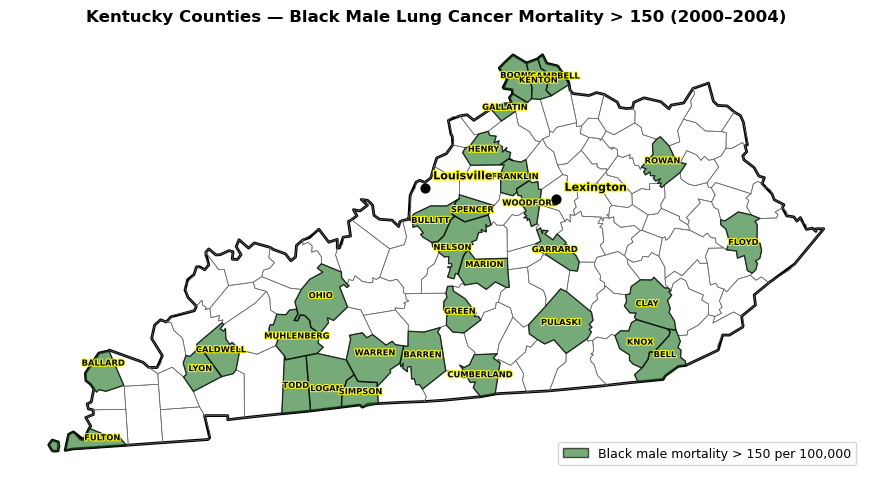


Exported: C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\outputs\maps\Assignment2_2A_Oladeji.jpg


In [47]:
# 13. Map A — Counties with Black male mortality > 150

fig, ax = plt.subplots(figsize=(11, 8))
plot_kentucky_lung_cancer_map(
    ax,
    highlight=sel_black,
    highlight_color="#2E7D32",
    highlight_label="Black male mortality > 150 per 100,000",
    title="Kentucky Counties — Black Male Lung Cancer Mortality > 150 (2000–2004)",
)
out_a = MAPS_DIR / "Assignment2_2A_Oladeji.jpg"
fig.savefig(out_a, dpi=300, bbox_inches="tight", format="jpeg")
plt.show()
print(f"\nExported: {out_a}")

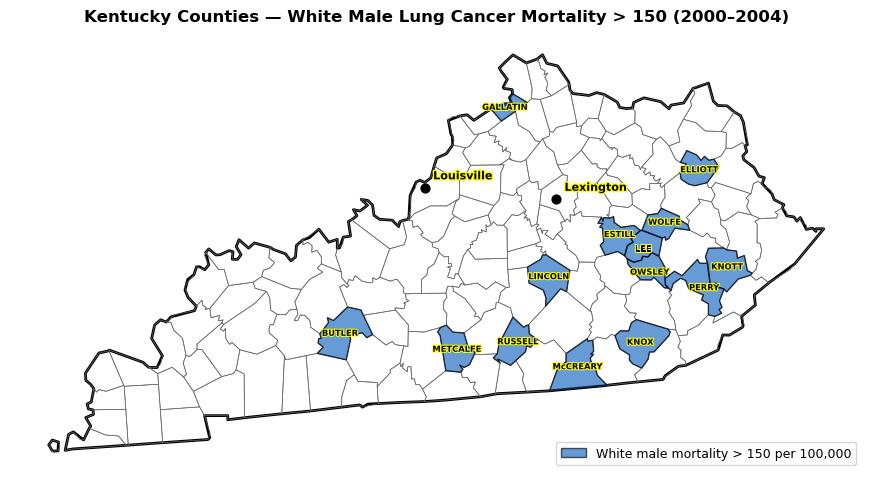


Exported: C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\outputs\maps\Assignment2_2B_Oladeji.jpg


In [49]:
# 14. Map B — Counties with White male mortality > 150

fig, ax = plt.subplots(figsize=(11, 8))
plot_kentucky_lung_cancer_map(
    ax,
    highlight=sel_white,
    highlight_color="#1565C0",
    highlight_label="White male mortality > 150 per 100,000",
    title="Kentucky Counties — White Male Lung Cancer Mortality > 150 (2000–2004)",
)
out_b = MAPS_DIR / "Assignment2_2B_Oladeji.jpg"
fig.savefig(out_b, dpi=300, bbox_inches="tight", format="jpeg")
plt.show()
print(f"\nExported: {out_b}")

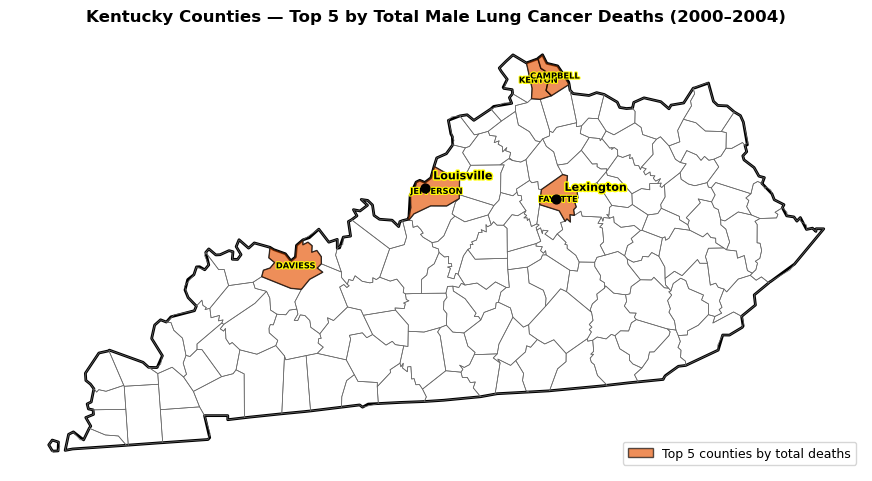


Exported: C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\outputs\maps\Assignment2_2C_Oladeji.jpg


In [51]:
# 15. Map C — Top 5 counties by total male lung cancer death count

fig, ax = plt.subplots(figsize=(11, 8))
plot_kentucky_lung_cancer_map(
    ax,
    highlight=sel_top5_count,
    highlight_color="#E65100",
    highlight_label="Top 5 counties by total deaths",
    title="Kentucky Counties — Top 5 by Total Male Lung Cancer Deaths (2000–2004)",
)
out_c = MAPS_DIR / "Assignment2_2C_Oladeji.jpg"
fig.savefig(out_c, dpi=300, bbox_inches="tight", format="jpeg")
plt.show()
print(f"\nExported: {out_c}")

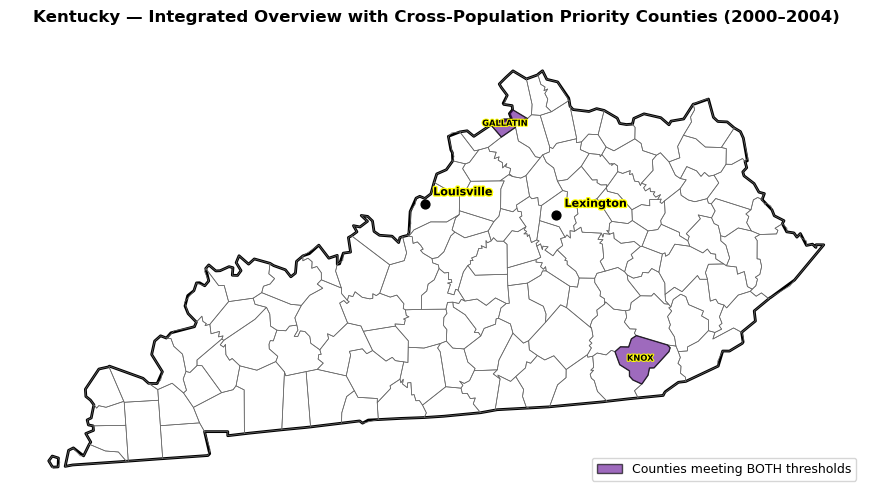


Exported: C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\outputs\maps\Assignment2_2D_Oladeji.jpg


In [53]:
# 16. Map D — Overview with overlap counties highlighted
# This is the 'all layers turned on' map — we add the overlap counties (counties
# meeting BOTH threshold criteria) as the highlighted set, since those are the
# analytically most important counties in the assignment.

fig, ax = plt.subplots(figsize=(11, 8))
plot_kentucky_lung_cancer_map(
    ax,
    highlight=overlap_counties,
    highlight_color="#6A1B9A",
    highlight_label="Counties meeting BOTH thresholds",
    title="Kentucky — Integrated Overview with Cross-Population Priority Counties (2000–2004)",
)
out_d = MAPS_DIR / "Assignment2_2D_Oladeji.jpg"
fig.savefig(out_d, dpi=300, bbox_inches="tight", format="jpeg")
plt.show()
print(f"\nExported: {out_d}")

## Step 8: Composite 2×2 summary figure

The four perspectives composited into a single figure for at-a-glance comparison — the portfolio-friendly visualization for the assignment subfolder README.

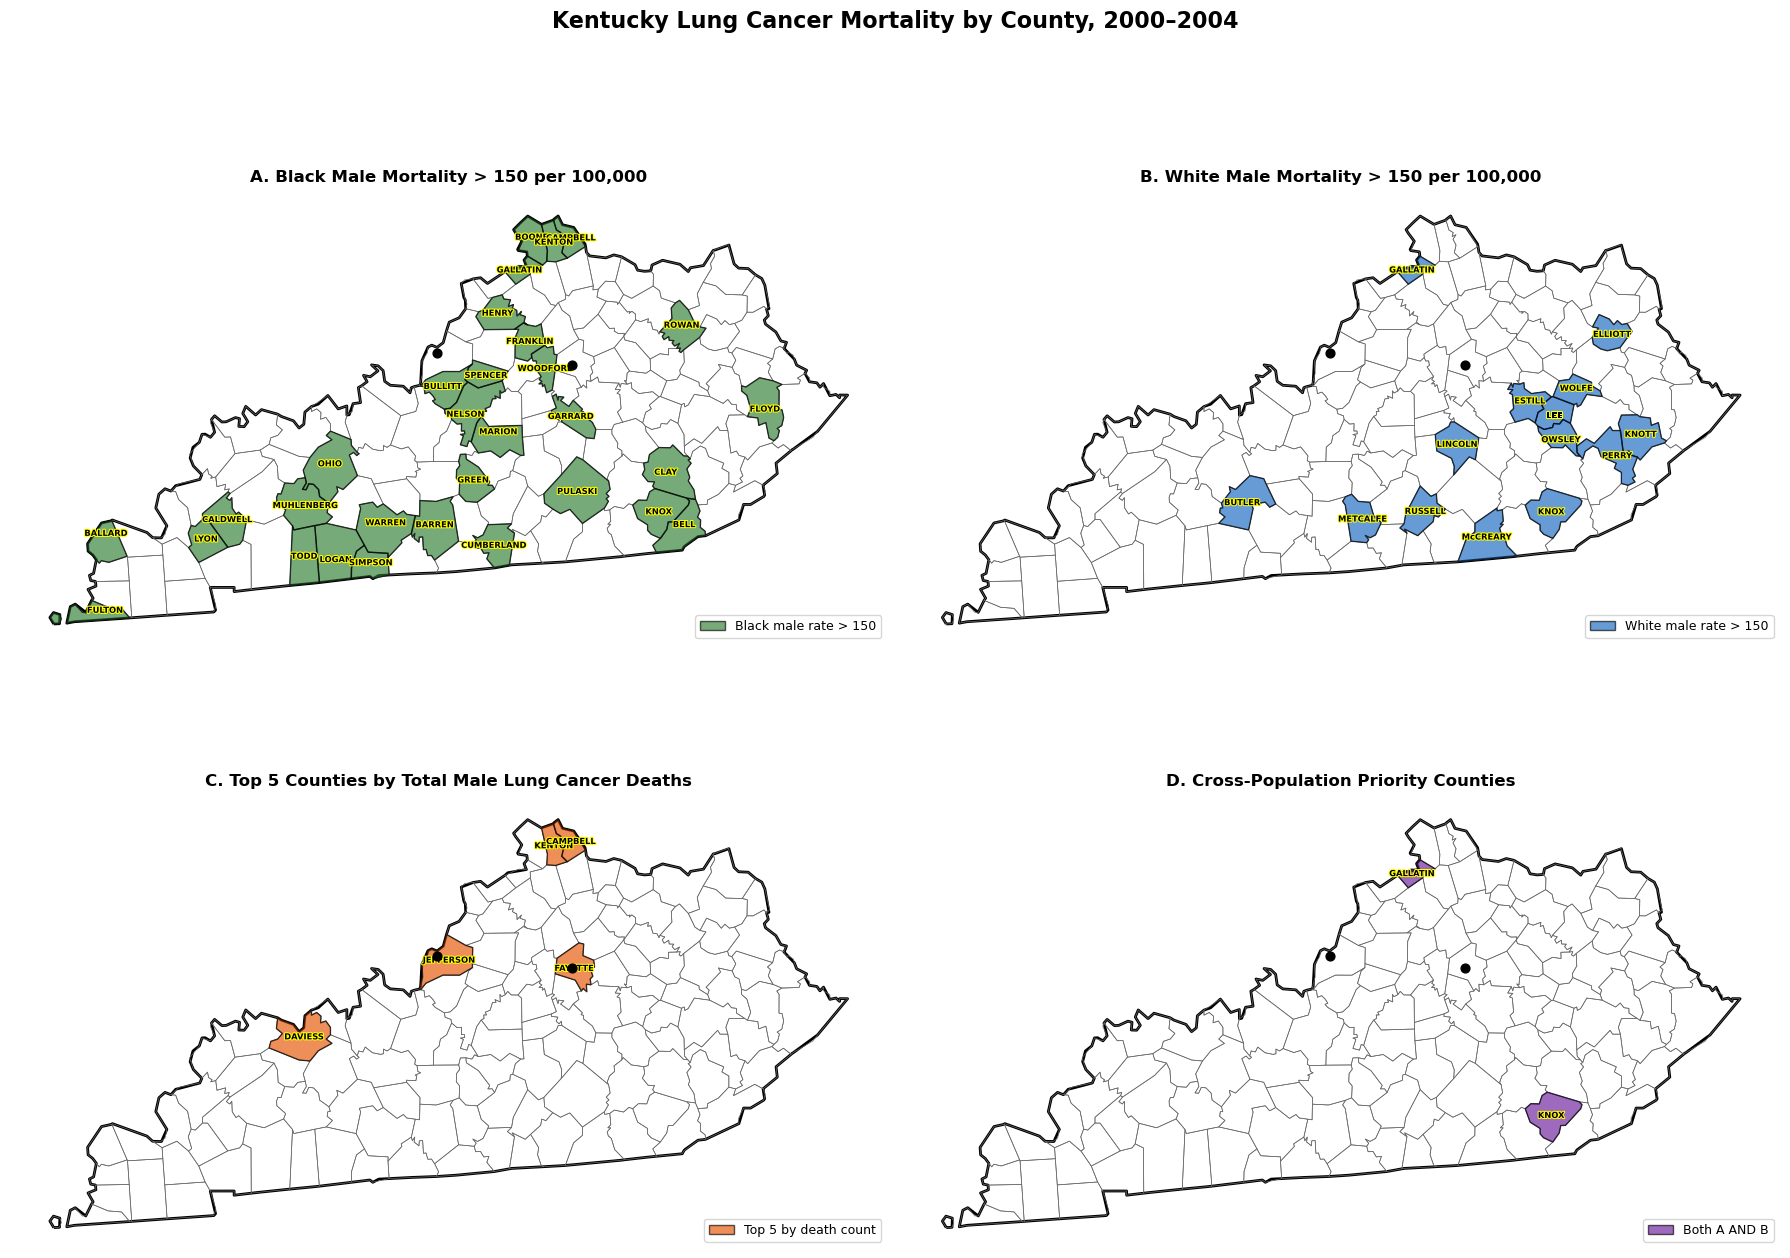


Exported: C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\outputs\maps\Assignment2_2_Summary_2x2_Oladeji.jpg


In [56]:
# 17. 2x2 summary figure

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

plot_kentucky_lung_cancer_map(
    axes[0, 0],
    highlight=sel_black,
    highlight_color="#2E7D32",
    highlight_label="Black male rate > 150",
    title="A. Black Male Mortality > 150 per 100,000",
    label_cities=False,
)

plot_kentucky_lung_cancer_map(
    axes[0, 1],
    highlight=sel_white,
    highlight_color="#1565C0",
    highlight_label="White male rate > 150",
    title="B. White Male Mortality > 150 per 100,000",
    label_cities=False,
)

plot_kentucky_lung_cancer_map(
    axes[1, 0],
    highlight=sel_top5_count,
    highlight_color="#E65100",
    highlight_label="Top 5 by death count",
    title="C. Top 5 Counties by Total Male Lung Cancer Deaths",
    label_cities=False,
)

plot_kentucky_lung_cancer_map(
    axes[1, 1],
    highlight=overlap_counties,
    highlight_color="#6A1B9A",
    highlight_label="Both A AND B",
    title="D. Cross-Population Priority Counties",
    label_cities=False,
)

fig.suptitle(
    "Kentucky Lung Cancer Mortality by County, 2000–2004",
    fontsize=16, fontweight="bold", y=0.995,
)
plt.tight_layout()

out_summary = MAPS_DIR / "Assignment2_2_Summary_2x2_Oladeji.jpg"
fig.savefig(out_summary, dpi=300, bbox_inches="tight", format="jpeg")
plt.show()
print(f"\nExported: {out_summary}")

## Step 9: Key Findings 

The assignment requires identifying the two counties whose **Black AND White** male mortality rates were **both** over 150 per 100,000. The cell below extracts this directly.

In [59]:
# 18. Final summary — the assignment's required finding

print("=" * 70)
print("KEY FINDING — Cross-Population High-Burden Counties")
print("=" * 70)
print(f"\nCounties where BOTH Black AND White male mortality rates")
print(f"exceeded 150 per 100,000 (2000–2004):\n")

if len(overlap_counties) > 0:
    summary = (overlap_counties[[COUNTY_NAME_COL, "RBM00_04", "RWM00_04", "CWMBM00_04"]]
               .sort_values("CWMBM00_04", ascending=False)
               .reset_index(drop=True))
    summary.columns = ["County", "Black Male Rate", "White Male Rate", "Total Deaths"]
    print(summary.to_string(index=False))

    # Save for the PowerPoint
    summary.to_csv(TABLES_DIR / "kentucky_overlap_counties.csv", index=False)
    print(f"\nSaved to: {TABLES_DIR / 'kentucky_overlap_counties.csv'}")
else:
    print("(No counties met both thresholds.)")

KEY FINDING — Cross-Population High-Burden Counties

Counties where BOTH Black AND White male mortality rates
exceeded 150 per 100,000 (2000–2004):

  County  Black Male Rate  White Male Rate  Total Deaths
    KNOX         180.3368         151.6648         106.0
GALLATIN         449.9833         181.0395          29.0

Saved to: C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\outputs\tables\kentucky_overlap_counties.csv


## Step 10: Patterns Observed 

Based on the county-level analysis above, four patterns warrant discussion in the  deliverable:

**Concentration of White male mortality in eastern Kentucky:** According to the Map B selection, 14 of 120 Kentucky counties exhibit White male lung cancer mortality rates exceeding 150 per 100,000, and these counties form a distinct cluster across the eastern Appalachian region, including Lee, Owsley, Knott, McCreary, Knox, Perry, and surrounding counties. In line with documented epidemiological patterns, this concentration is consistent with the region's history of coal-mining employment, elevated smoking prevalence, occupational respiratory exposure, and persistent disparities in healthcare access. Among the 120 Kentucky counties, the eastern Appalachian cluster contains the most spatially coherent high-mortality signal in the analysis.

**Statistical fragility of county-level Black male rates:** Of the 120 Kentucky counties, 55 counties (45.8%) recorded a Black male mortality rate of zero in the source data, almost certainly reflecting absent or negligible Black populations rather than true zero mortality. According to standard public health practice, these values are best treated as missing. Of the remaining 65 counties with non-zero values, 31 exceeded the 150-per-100,000 threshold (Map A), but the spatial dispersion of these counties, many in low-population rural areas, suggests that several may represent small-numerator artifacts rather than genuinely elevated burden. This methodological caveat is essential for responsible interpretation: race-specific county-level rates in low-diversity states are inherently fragile and should not be interpreted with the same weight as population-stable estimates.

**Concentration of total mortality burden in urban counties:** Based on the Map C selection, the top five counties by total male lung cancer death count (CWMBM00_04) include Jefferson (Louisville), Fayette (Lexington), Campbell, Kenton, and Daviess, the state's most populous urban centers. This pattern reflects population denominators rather than elevated per-capita risk: more people means more cases, even at average rates. The contrast between Map B (where high-rate counties cluster in rural Appalachia) and Map C (where high-count counties cluster around urban areas) illustrates a fundamental principle of public health surveillance, rates identify where risk is elevated, while counts identify where total burden is concentrated. Effective intervention strategy requires both perspectives: rural Appalachia for targeted risk reduction, urban centers for absolute case-volume management.

**Cross-population priority counties:** Gallatin and Knox. Based on the overlap analysis (Map D), exactly two counties exceed the 150-per-100,000 threshold for both Black and White male mortality simultaneously: Gallatin County in northern Kentucky and Knox County in the southeastern Appalachian region. These two counties warrant distinct interpretation. Knox County is consistent with the broader eastern Kentucky pattern, its elevated mortality across both racial groups likely reflects shared regional drivers including occupational exposure, smoking prevalence, and limited healthcare access. Gallatin County, in contrast, is one of Kentucky's smallest counties by population, and its appearance in the overlap may partly reflect small-numerator instability in its Black male mortality estimate. From a public health resource allocation perspective, Knox County represents a high-confidence priority target for cross-population intervention, while Gallatin warrants further investigation to distinguish a genuine high-burden signal from a statistical artifact.


## Reproducibility & Portfolio Notes

- **Data:** Not committed to the repository. Sources: NCI Cancer Mortality Maps (https://gis.cancer.gov) and ESRI sample data. The packaged `.gdb` files are from the *GIS Tutorial for Health* (Kurland & Gorr) companion data.
- **Environment:** `geopandas ≥ 0.14`, `matplotlib ≥ 3.7`, `pandas ≥ 2.0`, `pyogrio ≥ 0.7`.
- **Helper function design:** A single `plot_kentucky_lung_cancer_map()` function produces all five figures (four individual maps plus the 2×2 summary), ensuring consistent cartographic styling and minimizing duplicated plotting code.
- **Cartographic notes:**
  - All maps are reprojected to Albers Equal Area Conic (`EPSG:5070`) for consistency with Assignment 2-1.
  - Highlighted county labels use `matplotlib.patheffects.withStroke` to approximate the ArcGIS Pro yellow halo mask.
  - City labels are offset 6 points from the marker to avoid overlap; this approximates ArcGIS Pro's auto-placement.
- **Threshold methodology:** Counties with missing race-specific rates are excluded from the threshold selection rather than treated as zeros. This is the standard approach in public health surveillance.
